# 🧠 Parkinson's Disease Detection from Speech
## SOTA: MFCC(39) + Breathiness + Entropy Suite + Dual-Domain Wavelet + Best-Single-Model
### Features: MFCC(39d) | PPQ,APQ,HE,GNER,HRes,HSR,HNR,CPP | Shannon,Renyi,Permutation,Approximate,Spectral Entropy | DWT+WPT+TBR
### Design: Cache → StratifiedGroupKFold → RobustScaler → SelectKBest → XGBoost/SVM (auto-select best)

In [1]:
# ── CELL 1: Install dependencies ──────────────────────────────────────────────
import subprocess, sys
pkgs = ['librosa','PyWavelets','scikit-learn','soundfile','tqdm',
        'seaborn','matplotlib','pandas','numpy','scipy','xgboost','praat-parselmouth','antropy']
for p in pkgs:
    subprocess.run([sys.executable,'-m','pip','install',p,'-q'], check=False)
print('✅ Packages ready')

✅ Packages ready


In [2]:
# ── CELL 2: Imports ────────────────────────────────────────────────────────────
import os, sys, time, random, warnings, gc, hashlib
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import librosa
import pywt
import soundfile as sf
from scipy import stats
from scipy.signal import periodogram, hilbert, butter, filtfilt
from scipy.fft import fft, fftfreq
import parselmouth
from parselmouth.praat import call

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef
)
import xgboost as xgb

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('✅ Imports OK')

✅ Imports OK


In [3]:
# ── CELL 3: Configuration ──────────────────────────────────────────────────────
BASE_PATH   = r'E:\miniproject\PD'
OUTPUT_DIR  = 'pd_sota_results'
CACHE_DIR   = os.path.join(OUTPUT_DIR, 'cache')

# Only vowels that exist in PC-GITA (sustained vowels a,e,i,o,u)
# Adjust this list to exactly match your folder names
VOWELS      = ['A', 'E', 'I', 'O', 'U']

SR          = 16000
DURATION    = 3       # seconds to use per file
N_FOLDS     = 5

# Wavelet settings
DWT_WAVELET = 'db4'
DWT_LEVEL   = 5
WPT_LEVEL   = 4

# Audio frame settings
FRAME_LEN   = int(0.025 * SR)   # 25 ms
HOP_LEN     = int(0.010 * SR)   # 10 ms

# Feature dimensions
N_MFCC      = 13   # → 39D with deltas
N_BREATH    = 9    # PPQ,APQ,HE,GNER,HRes,HSR,HNR,HNR_std,CPP
N_ENTROPY   = 5    # Shannon,Renyi,Permutation,Approximate,Spectral
N_WAVELET   = 57   # DWT+WPT+TBR
TOTAL_FEAT  = 39 + N_BREATH + N_ENTROPY + N_WAVELET  # = 110

for sub in ['graphs','reports','models', 'cache']:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

print(f'✅ Config OK | SR={SR} | Folds={N_FOLDS} | Total features={TOTAL_FEAT}')

✅ Config OK | SR=16000 | Folds=5 | Total features=110


In [4]:
# ── CELL 4: Audio Utilities ────────────────────────────────────────────────────
def load_audio(path):
    try:
        sig, sr = sf.read(path, always_2d=False)
        if sig.ndim > 1: sig = sig.mean(axis=1)
        if sr != SR:
            sig = librosa.resample(sig.astype(np.float32), orig_sr=sr, target_sr=SR)
        return sig.astype(np.float32), SR
    except Exception:
        return None, None

def preemphasis(sig, coef=0.97):
    return np.append(sig[0], sig[1:] - coef * sig[:-1])

def vad_trim(sig):
    trimmed, _ = librosa.effects.trim(sig, top_db=30)
    return trimmed if len(trimmed) > SR * 0.2 else sig

def prepare(path):
    sig, _ = load_audio(path)
    if sig is None: return None
    sig = preemphasis(sig)
    sig = vad_trim(sig)
    target = SR * DURATION
    sig = sig[:target] if len(sig) >= target else np.pad(sig, (0, target - len(sig)))
    mx = np.max(np.abs(sig))
    if mx > 0: sig = sig / mx
    return sig.astype(np.float32)

def _s(v):
    v = float(v)
    return 0.0 if (np.isnan(v) or np.isinf(v)) else v

print('✅ Audio utilities ready')

✅ Audio utilities ready


In [5]:
# ── CELL 5: MFCC Features (39D) ───────────────────────────────────────────────
def mfcc_features(sig, sr=SR):
    """
    39-D MFCC: 13 MFCC + 13 Delta + 13 Delta-Delta
    Returns mean of each coefficient over time → 39 scalars
    """
    mfcc  = librosa.feature.mfcc(y=sig, sr=sr, n_mfcc=N_MFCC,
                                  n_fft=512, hop_length=HOP_LEN)
    d1    = librosa.feature.delta(mfcc)
    d2    = librosa.feature.delta(mfcc, order=2)
    # Concatenate mean of each row → 13+13+13 = 39
    feats = np.concatenate([
        np.mean(mfcc, axis=1),
        np.mean(d1,   axis=1),
        np.mean(d2,   axis=1)
    ])
    return feats.astype(np.float32)  # shape (39,)

print('✅ MFCC (39D) ready')

✅ MFCC (39D) ready


In [6]:
# ── CELL 6: Breathiness Features (9D) ─────────────────────────────────────────
# PPQ, APQ, HE, GNER, HRes, HSR, HNR, HNR_std, CPP
# Reference: Paper equations provided in brief

def breathiness_features(path):
    """
    9 breathiness/phonatory features:
    [0] PPQ  - Period Perturbation Quotient (jitter variant, smoothing=3)
    [1] APQ  - Amplitude Perturbation Quotient (shimmer variant, smoothing=7)
    [2] HE   - Harmonic Energy (H1/H2 ratio from spectrum)
    [3] GNER - Glottal-to-Noise Excitation Ratio proxy
    [4] HRes - Harmonic Energy of Residue (H1/H2 of LPC residual)
    [5] HSR  - Harmonic-to-Signal Ratio (sum of harmonic peaks / total energy)
    [6] HNR  - Harmonic-to-Noise Ratio mean (dB)
    [7] HNR_std - HNR standard deviation
    [8] CPP  - Cepstral Peak Prominence
    """
    feats = [0.0] * 9
    try:
        snd = parselmouth.Sound(path)
        snd = snd.resample(SR)
        dur = snd.duration

        # ── PointProcess for jitter/shimmer ──
        pp = call(snd, 'To PointProcess (periodic, cc)', 75.0, 600.0)

        # [0] PPQ (jitter ppq5 ≈ smoothing=5, closest to J3/PPQ3)
        try:
            feats[0] = _s(call(pp, 'Get jitter (ppq5)', 0, 0, 0.0001, 0.02, 1.3))
        except: pass

        # [1] APQ (shimmer apq11 ≈ smoothing=7)
        try:
            feats[1] = _s(call([snd, pp], 'Get shimmer (apq11)', 0, 0, 0.0001, 0.02, 1.3, 1.6))
        except: pass

        # [6,7] HNR mean & std
        try:
            hnr_obj   = call(snd, 'To Harmonicity (cc)', 0.01, 75.0, 0.1, 1.0)
            hnr_mean  = call(hnr_obj, 'Get mean', 0, 0)
            hnr_std   = call(hnr_obj, 'Get standard deviation', 0, 0)
            feats[6]  = _s(hnr_mean)
            feats[7]  = _s(hnr_std)
        except: pass

        # [8] CPP - Cepstral Peak Prominence
        try:
            powercepstrogram = call(snd, 'To PowerCepstrogram', 60.0, 0.002, 5000.0, 50.0)
            cpp_val = call(powercepstrogram, 'Get CPPS', 'yes', 0.02, 0.0, 60.0, 330.0,
                           0.05, 'Parabolic', 0.001, 0.0, 'Straight', 'Robust')
            feats[8] = _s(cpp_val)
        except: pass

    except Exception:
        pass

    # ── Signal-level features (GNER, HE, HRes, HSR) using librosa/numpy ──
    try:
        sig, sr = load_audio(path)
        if sig is not None and len(sig) > SR * 0.1:
            sig32 = sig.astype(np.float32)

            # [3] GNER proxy: noise energy ratio in high-freq band
            harm   = librosa.effects.harmonic(sig32)
            noise  = sig32 - harm
            feats[3] = _s(np.sum(noise**2) / (np.sum(sig32**2) + 1e-12))

            # [2] HE: H1/H2 from magnitude spectrum
            # Estimate F0 first
            f0_arr = librosa.yin(sig32, fmin=75, fmax=600, sr=SR)
            f0_arr = f0_arr[f0_arr > 0]
            if len(f0_arr) > 5:
                f0_med = float(np.median(f0_arr))
                N_fft  = 1024
                mag    = np.abs(np.fft.rfft(sig32[:N_fft] if len(sig32) >= N_fft
                                            else np.pad(sig32,(0,N_fft-len(sig32))), n=N_fft))
                freqs  = np.fft.rfftfreq(N_fft, d=1.0/SR)
                # H1: peak near f0_med ± 5%
                h1_mask = np.abs(freqs - f0_med) < 0.05 * f0_med
                h2_mask = np.abs(freqs - 2*f0_med) < 0.05 * f0_med * 2
                H1 = float(np.max(mag[h1_mask])) if h1_mask.any() else 1e-9
                H2 = float(np.max(mag[h2_mask])) if h2_mask.any() else 1e-9
                feats[2] = _s(H1 / (H2 + 1e-9))

                # [4] HRes: H1/H2 of LPC residual
                try:
                    # LPC order 13, get residual
                    from scipy.signal import lfilter
                    lpc_coeffs = librosa.lpc(sig32, order=13)
                    residual   = lfilter(lpc_coeffs, [1.0], sig32)
                    res_chunk  = residual[:N_fft] if len(residual)>=N_fft else np.pad(residual,(0,N_fft-len(residual)))
                    res_mag    = np.abs(np.fft.rfft(res_chunk, n=N_fft))
                    rH1 = float(np.max(res_mag[h1_mask])) if h1_mask.any() else 1e-9
                    rH2 = float(np.max(res_mag[h2_mask])) if h2_mask.any() else 1e-9
                    feats[4] = _s(rH1 / (rH2 + 1e-9))
                except: pass

                # [5] HSR: sum of first 10 harmonic peaks / total spectral energy
                harmonic_energy = 0.0
                for k in range(1, 11):
                    hk_freq = k * f0_med
                    hk_mask = np.abs(freqs - hk_freq) < 0.05 * hk_freq
                    if hk_mask.any():
                        harmonic_energy += float(np.max(mag[hk_mask]))**2
                total_energy = float(np.sum(mag**2)) + 1e-12
                feats[5] = _s(harmonic_energy / total_energy)

    except Exception:
        pass

    return feats  # length 9

print('✅ Breathiness features (9D) ready')

✅ Breathiness features (9D) ready


In [7]:
# ── CELL 7: Entropy Features (5D) ─────────────────────────────────────────────
# Shannon, Renyi, Permutation, Approximate, Spectral Entropy

def _bandpass(x, lo, hi, sr=SR):
    b, a = butter(4, [lo/(sr/2), hi/(sr/2)], btype='band')
    return filtfilt(b, a, x)

def shannon_entropy(sig):
    hist, _ = np.histogram(sig, bins=50)
    p = hist[hist > 0].astype(float)
    p /= p.sum()
    return _s(-np.sum(p * np.log2(p + 1e-12)))

def renyi_entropy(sig, beta=2.0):
    """Renyi entropy of order beta on power spectrum (eq. 12 from paper)"""
    _, Pxx = periodogram(sig, SR, nfft=512)
    Pxx = Pxx / (Pxx.sum() + 1e-12)
    Pxx = Pxx[Pxx > 0]
    return _s((1.0 / (1.0 - beta)) * np.log2(np.sum(Pxx**beta) + 1e-12))

def permutation_entropy(sig, d=3, tau=1):
    """Permutation entropy (eq. 13-15 from paper)"""
    N = len(sig)
    from itertools import permutations
    import math
    patterns = {}
    total = 0
    for i in range(N - (d-1)*tau):
        vec = tuple(sig[i + j*tau] for j in range(d))
        key = tuple(np.argsort(vec))
        patterns[key] = patterns.get(key, 0) + 1
        total += 1
    if total == 0: return 0.0
    pe = 0.0
    for count in patterns.values():
        p = count / total
        pe -= p * np.log2(p + 1e-12)
    return _s(pe)

def approximate_entropy(sig, m=2, r_factor=0.2):
    """Approximate entropy - fast implementation"""
    sig = sig[:1000]  # use first 1000 samples for speed
    N = len(sig)
    r = r_factor * np.std(sig)
    if r == 0: return 0.0
    def phi(m_):
        count = 0
        for i in range(N - m_):
            template = sig[i:i+m_]
            for j in range(N - m_):
                if np.max(np.abs(template - sig[j:j+m_])) <= r:
                    count += 1
        return np.log(count / (N - m_) + 1e-12)
    try:
        return _s(phi(m) - phi(m+1))
    except:
        return 0.0

def spectral_entropy(sig, sr=SR):
    """Spectral entropy from normalized PSD"""
    _, Pxx = periodogram(sig, sr, nfft=512)
    Pxx = Pxx / (Pxx.sum() + 1e-12)
    Pxx_pos = Pxx[Pxx > 0]
    return _s(-np.sum(Pxx_pos * np.log2(Pxx_pos)))

def entropy_features(sig, sr=SR):
    """5 entropy features: Shannon, Renyi, Permutation, Approximate, Spectral"""
    # Use downsampled signal for speed in ApEn
    sig_ds = sig[::4]  # 4kHz for entropy
    return [
        shannon_entropy(sig),
        renyi_entropy(sig),
        permutation_entropy(sig_ds[:500], d=3, tau=1),
        approximate_entropy(sig_ds[:500]),
        spectral_entropy(sig)
    ]

print('✅ Entropy features (5D) ready')

✅ Entropy features (5D) ready


In [8]:
# ── CELL 8: Dual-Domain Wavelet Features (57D) ────────────────────────────────
# WPT energy+entropy + DWT detail stats + TBR + envelope tremor bands

def wavelet_features(sig, sr=SR):
    """
    57 Dual-Domain Wavelet Features:
    - WPT: 16 energy + 16 normalized energy = 32
    - Envelope tremor bands (2,4),(4,7),(7,12),(12,20): energy+std = 8
    - TBR (tremor band ratio 3-7 Hz): 1
    - Instantaneous freq std in top-4 WPT nodes: 4
    - DWT detail stats (3 levels × 4 stats): 12
    Total = 32+8+1+4+12 = 57
    """
    feats = []

    # 1. WPT (32 features)
    wp = pywt.WaveletPacket(data=sig, wavelet=DWT_WAVELET, mode='symmetric', maxlevel=WPT_LEVEL)
    nodes = [n.path for n in wp.get_level(WPT_LEVEL, 'natural')]
    energies = [float(np.sum(wp[nd].data**2) / (len(wp[nd].data) + 1e-12)) for nd in nodes]
    total_e  = sum(energies) + 1e-12
    feats += energies + [e / total_e for e in energies]

    # 2. Envelope tremor bands (8 features)
    env = np.abs(hilbert(sig))
    for lo, hi in [(2, 4), (4, 7), (7, 12), (12, 20)]:
        try:
            filtered = _bandpass(env, lo, hi, sr)
            feats.extend([
                float(np.sum(filtered**2) / (len(filtered) + 1e-12)),
                float(np.std(filtered))
            ])
        except:
            feats.extend([0.0, 0.0])

    # 3. TBR (1 feature) - tremor band ratio 3-7 Hz
    try:
        tremor_env = _bandpass(env, 3, 7, sr)
        feats.append(_s(np.sum(tremor_env**2) / (np.sum(env**2) + 1e-12)))
    except:
        feats.append(0.0)

    # 4. Instantaneous freq std in top-4 energy WPT nodes (4 features)
    top4 = sorted(range(len(nodes)), key=lambda i: -energies[i])[:4]
    for idx in top4:
        coef = wp[nodes[idx]].data
        if len(coef) > 2:
            analytic = hilbert(coef)
            inst_freq = np.diff(np.unwrap(np.angle(analytic))) / (2 * np.pi)
            feats.append(_s(np.std(inst_freq)))
        else:
            feats.append(0.0)

    # 5. DWT detail stats (12 features: 3 levels × 4 stats)
    coeffs = pywt.wavedec(sig, DWT_WAVELET, level=3)
    for c in coeffs[1:]:  # detail coefficients d1,d2,d3
        feats.extend([
            float(np.sum(c**2)),
            float(np.std(c)),
            float(stats.kurtosis(c)),
            float(stats.skew(c))
        ])

    # Pad/trim to exactly 57
    while len(feats) < 57: feats.append(0.0)
    return feats[:57]

print('✅ Wavelet features (57D) ready')

✅ Wavelet features (57D) ready


In [9]:
# ── CELL 9: Combined Feature Extraction + Per-File Cache ──────────────────────

def get_cache_path(filepath):
    """Unique cache file per audio path"""
    h = hashlib.md5(filepath.encode()).hexdigest()[:12]
    return os.path.join(CACHE_DIR, f'{h}.npy')

def extract_all_features(path):
    """Extract all features with per-file caching."""
    cache_path = get_cache_path(path)
    if os.path.exists(cache_path):
        arr = np.load(cache_path)
        if len(arr) == TOTAL_FEAT:
            return arr
    try:
        sig = prepare(path)
        if sig is None: return None

        m = mfcc_features(sig)               # 39
        b = breathiness_features(path)       # 9
        e = entropy_features(sig)            # 5
        w = wavelet_features(sig)            # 57

        vec = list(m) + list(b) + list(e) + list(w)
        arr = np.nan_to_num(np.array(vec, dtype=np.float32))
        arr = arr[:TOTAL_FEAT] if len(arr) >= TOTAL_FEAT else np.pad(arr, (0, TOTAL_FEAT - len(arr)))

        np.save(cache_path, arr)
        return arr
    except Exception as ex:
        return None

print(f'✅ Feature pipeline ready | Total dims = {TOTAL_FEAT} (39 MFCC + 9 Breath + 5 Entropy + 57 Wavelet)')

✅ Feature pipeline ready | Total dims = 110 (39 MFCC + 9 Breath + 5 Entropy + 57 Wavelet)


In [10]:
# ── CELL 10: Dataset Scanning ──────────────────────────────────────────────────
# PC-GITA structure: BASE_PATH / Vowel / Healthy|PD / *.wav
# Expected: ~850 Healthy + ~850 PD = ~1700 files total

def extract_speaker_id(path):
    """Extract speaker ID from filename.
    PC-GITA files: AVPEPUDEA0001.wav → AVPEPUDEA0001 (speaker)
    Common pattern: <ID>_<repetition>.wav OR just <ID>.wav
    """
    stem = Path(path).stem
    parts = stem.split('_')
    # If last part is a small digit (repetition index), remove it
    if len(parts) >= 2 and parts[-1].isdigit() and len(parts[-1]) <= 2:
        return '_'.join(parts[:-1])
    return stem  # whole filename = speaker (1 file per speaker per vowel)

def scan_dataset(base_path):
    base = Path(base_path)
    records = []
    found_vowels = []
    print(f'\n📁 Scanning: {base}')
    for vowel in VOWELS:
        # Try both original case and lowercase
        vpath = base / vowel
        if not vpath.exists(): vpath = base / vowel.lower()
        if not vpath.exists():
            print(f'  ⚠️  Vowel folder not found: {vowel}')
            continue
        found_vowels.append(vowel)
        for label_name, label_val in [('Healthy', 0), ('PD', 1)]:
            lpath = vpath / label_name
            if not lpath.exists(): lpath = vpath / label_name.lower()
            if not lpath.exists():
                print(f'  ⚠️  Label folder not found: {vowel}/{label_name}')
                continue
            files = list(lpath.glob('*.wav')) + list(lpath.glob('*.WAV'))
            for f in files:
                records.append({
                    'path'   : str(f),
                    'label'  : label_val,
                    'vowel'  : vowel,
                    'speaker': extract_speaker_id(str(f))
                })
    print(f'  Found vowels: {found_vowels}')
    print(f'  Total files : {len(records)}')
    # Class balance
    if records:
        df = pd.DataFrame(records)
        print('  Label distribution:')
        print(df.groupby(['vowel','label']).size().to_string())
        n_speakers = df['speaker'].nunique()
        print(f'  Unique speakers: {n_speakers}')
    return records

records = scan_dataset(BASE_PATH)
print(f'\n✅ TOTAL: {len(records)} files (expected ~1700)')


📁 Scanning: E:\miniproject\PD
  Found vowels: ['A', 'E', 'I', 'O', 'U']
  Total files : 3000
  Label distribution:
vowel  label
A      0        300
       1        300
E      0        300
       1        300
I      0        300
       1        300
O      0        300
       1        300
U      0        300
       1        300
  Unique speakers: 1500

✅ TOTAL: 3000 files (expected ~1700)


In [11]:
# ── CELL 11: Bulk Feature Extraction (with global cache) ──────────────────────

_X_path = os.path.join(OUTPUT_DIR, 'X_all.npy')
_y_path = os.path.join(OUTPUT_DIR, 'y_all.npy')
_v_path = os.path.join(OUTPUT_DIR, 'v_all.npy')
_s_path = os.path.join(OUTPUT_DIR, 's_all.npy')

if all(os.path.exists(p) for p in [_X_path, _y_path, _v_path, _s_path]):
    X_all = np.load(_X_path)
    y_all = np.load(_y_path)
    v_all = np.load(_v_path, allow_pickle=True)
    s_all = np.load(_s_path, allow_pickle=True)
    print(f'✅ Loaded cached dataset: {X_all.shape}')
    print(f'   Labels: {np.bincount(y_all)} (Healthy/PD)')
else:
    all_feats, all_labels, all_vowels, all_spk = [], [], [], []
    failed = 0
    for rec in tqdm(records, desc='Extracting features'):
        feat = extract_all_features(rec['path'])
        if feat is not None:
            all_feats.append(feat)
            all_labels.append(rec['label'])
            all_vowels.append(rec['vowel'])
            all_spk.append(rec['speaker'])
        else:
            failed += 1

    X_all = np.array(all_feats, dtype=np.float32)
    y_all = np.array(all_labels, dtype=np.int64)
    v_all = np.array(all_vowels)
    s_all = np.array(all_spk)

    np.save(_X_path, X_all)
    np.save(_y_path, y_all)
    np.save(_v_path, v_all)
    np.save(_s_path, s_all)

    print(f'✅ Extracted {X_all.shape} | Failed: {failed}')
    print(f'   Labels: {np.bincount(y_all)} (Healthy/PD)')

✅ Loaded cached dataset: (3400, 185)
   Labels: [1700 1700] (Healthy/PD)


In [12]:
# ── CELL 12: Metrics Helper ────────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = (cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0))
    return {
        'accuracy'    : float(accuracy_score(y_true, y_pred)),
        'balanced_acc': float(balanced_accuracy_score(y_true, y_pred)),
        'sensitivity' : tp / (tp + fn + 1e-12),   # recall for PD
        'specificity' : tn / (tn + fp + 1e-12),
        'f1'          : float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc'     : float(roc_auc_score(y_true, y_proba[:, 1])) if len(np.unique(y_true)) > 1 else 0.5,
        'mcc'         : float(matthews_corrcoef(y_true, y_pred)),
        'cm'          : cm
    }

print('✅ Metrics helper ready')

✅ Metrics helper ready


In [13]:
# ── CELL 13: Model Builder + Auto-Select ──────────────────────────────────────
# Use single best model: XGBoost (primary) or SVM-RBF (fallback)
# Only use ensemble if it meaningfully improves AUC

def build_xgb_pipeline(k_features=80):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('select', SelectKBest(f_classif, k=min(k_features, TOTAL_FEAT))),
        ('clf',    xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=SEED
        ))
    ])

def build_svm_pipeline(k_features=80):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('select', SelectKBest(f_classif, k=min(k_features, TOTAL_FEAT))),
        ('clf',    SVC(C=10, gamma='scale', kernel='rbf',
                       probability=True, random_state=SEED))
    ])

print('✅ Model builders ready (XGBoost primary, SVM fallback)')

✅ Model builders ready (XGBoost primary, SVM fallback)


In [14]:
# ── CELL 14: Per-Vowel Cross-Validation ───────────────────────────────────────
# Speaker-Independent: StratifiedGroupKFold (groups = speaker IDs)

vowel_results  = {}
vowel_pipelines = {}   # best fitted pipelines per vowel
vowel_fold_data = {}   # (true, pred, proba) per vowel

for vowel in VOWELS:
    mask = v_all == vowel
    if mask.sum() < 20:
        print(f'⚠️  {vowel}: only {mask.sum()} samples, skipping')
        continue

    Xv, yv, sv = X_all[mask], y_all[mask], s_all[mask]
    n_unique_spk = len(np.unique(sv))
    n_folds = min(N_FOLDS, n_unique_spk // 2)
    if n_folds < 2:
        print(f'⚠️  {vowel}: not enough speakers for CV')
        continue

    sgkf = StratifiedGroupKFold(n_splits=n_folds)
    all_true, all_pred, all_proba = [], [], []
    fitted_xgb, fitted_svm = [], []

    for fold, (tr_idx, te_idx) in enumerate(sgkf.split(Xv, yv, groups=sv)):
        X_tr, X_te = Xv[tr_idx], Xv[te_idx]
        y_tr, y_te = yv[tr_idx], yv[te_idx]

        # Train XGBoost
        pipe_xgb = build_xgb_pipeline()
        pipe_xgb.fit(X_tr, y_tr)
        yp_xgb  = pipe_xgb.predict(X_te)
        ypr_xgb = pipe_xgb.predict_proba(X_te)
        fitted_xgb.append(pipe_xgb)

        # Train SVM (quick check)
        pipe_svm = build_svm_pipeline()
        pipe_svm.fit(X_tr, y_tr)
        ypr_svm = pipe_svm.predict_proba(X_te)
        fitted_svm.append(pipe_svm)

        # Use XGBoost predictions (SVM used only for fusion if needed)
        all_true.extend(y_te)
        all_pred.extend(yp_xgb)
        all_proba.extend(ypr_xgb)

    all_true  = np.array(all_true)
    all_pred  = np.array(all_pred)
    all_proba = np.array(all_proba)

    m = compute_metrics(all_true, all_pred, all_proba)
    vowel_results[vowel]   = m
    vowel_pipelines[vowel] = {'xgb': fitted_xgb, 'svm': fitted_svm}
    vowel_fold_data[vowel] = (all_true, all_pred, all_proba)

    print(f'{vowel}: Acc={m["accuracy"]*100:.2f}% | AUC={m["roc_auc"]:.4f} | '
          f'Sens={m["sensitivity"]*100:.1f}% | Spec={m["specificity"]*100:.1f}% | '
          f'MCC={m["mcc"]:.3f}')

A: Acc=85.67% | AUC=0.9201 | Sens=85.3% | Spec=86.0% | MCC=0.713
E: Acc=82.67% | AUC=0.8818 | Sens=82.3% | Spec=83.0% | MCC=0.653
I: Acc=85.33% | AUC=0.9123 | Sens=84.0% | Spec=86.7% | MCC=0.707
O: Acc=82.17% | AUC=0.8999 | Sens=83.0% | Spec=81.3% | MCC=0.643
U: Acc=82.00% | AUC=0.8919 | Sens=79.7% | Spec=84.3% | MCC=0.641


In [15]:
# ── CELL 15: Token-Aware Late Fusion (Speaker-Level) ──────────────────────────
# Aggregate per-vowel probabilities at speaker level → meta-classifier

speaker_proba_by_vowel = defaultdict(dict)
speaker_label_map = {}

for vowel in vowel_results:
    mask = v_all == vowel
    Xv, yv, sv = X_all[mask], y_all[mask], s_all[mask]
    n_folds = len(vowel_pipelines[vowel]['xgb'])
    sgkf = StratifiedGroupKFold(n_splits=n_folds)

    for fold_i, (tr_idx, te_idx) in enumerate(sgkf.split(Xv, yv, groups=sv)):
        pipe = vowel_pipelines[vowel]['xgb'][fold_i]
        proba = pipe.predict_proba(Xv[te_idx])
        for i, spk in enumerate(sv[te_idx]):
            if vowel not in speaker_proba_by_vowel[spk]:
                speaker_proba_by_vowel[spk][vowel] = []
            speaker_proba_by_vowel[spk][vowel].append(proba[i, 1])
            speaker_label_map[spk] = int(yv[te_idx][i])

# Average fold probabilities per speaker per vowel
for spk in speaker_proba_by_vowel:
    for v in speaker_proba_by_vowel[spk]:
        speaker_proba_by_vowel[spk][v] = float(np.mean(speaker_proba_by_vowel[spk][v]))

vowel_keys = list(vowel_results.keys())
meta_X, meta_y, meta_spk = [], [], []
for spk in speaker_proba_by_vowel:
    row = [speaker_proba_by_vowel[spk].get(v, 0.5) for v in vowel_keys]
    row += [
        float(np.max(row)),
        float(np.min(row)),
        float(np.mean(row)),
        float(np.std(row)),
        float(np.argmax(row))
    ]
    meta_X.append(row)
    meta_y.append(speaker_label_map[spk])
    meta_spk.append(spk)

meta_X   = np.array(meta_X,   dtype=np.float32)
meta_y   = np.array(meta_y,   dtype=np.int64)
meta_spk = np.array(meta_spk)

print(f'Meta dataset: {meta_X.shape} | Speakers: {len(meta_y)} | '
      f'Labels: {np.bincount(meta_y)}')

Meta dataset: (1500, 10) | Speakers: 1500 | Labels: [750 750]


In [16]:
# ── CELL 16: Fusion Model Evaluation ──────────────────────────────────────────

fusion_m = None

if len(np.unique(meta_spk)) >= 6:
    n_meta_folds = min(5, len(np.unique(meta_spk)) // 2)
    sgkf_meta = StratifiedGroupKFold(n_splits=n_meta_folds)

    fusion_true, fusion_pred, fusion_proba = [], [], []

    for tr_idx, te_idx in sgkf_meta.split(meta_X, meta_y, groups=meta_spk):
        meta_clf = xgb.XGBClassifier(
            n_estimators=200, max_depth=3, learning_rate=0.05,
            subsample=0.8, use_label_encoder=False,
            eval_metric='logloss', random_state=SEED
        )
        meta_clf.fit(meta_X[tr_idx], meta_y[tr_idx])
        fusion_true.extend(meta_y[te_idx])
        fusion_pred.extend(meta_clf.predict(meta_X[te_idx]))
        fusion_proba.extend(meta_clf.predict_proba(meta_X[te_idx]))

    fusion_m = compute_metrics(
        np.array(fusion_true),
        np.array(fusion_pred),
        np.array(fusion_proba)
    )
    print(f'\n🔀 SPEAKER-LEVEL FUSION RESULT:')
    print(f'   Accuracy     : {fusion_m["accuracy"]*100:.2f}%')
    print(f'   Balanced Acc : {fusion_m["balanced_acc"]*100:.2f}%')
    print(f'   AUC          : {fusion_m["roc_auc"]:.4f}')
    print(f'   Sensitivity  : {fusion_m["sensitivity"]*100:.2f}%')
    print(f'   Specificity  : {fusion_m["specificity"]*100:.2f}%')
    print(f'   MCC          : {fusion_m["mcc"]:.4f}')
    print(f'   F1           : {fusion_m["f1"]:.4f}')
else:
    print('⚠️  Not enough unique speakers for fusion CV. Showing per-vowel results only.')


🔀 SPEAKER-LEVEL FUSION RESULT:
   Accuracy     : 82.27%
   Balanced Acc : 82.27%
   AUC          : 0.8880
   Sensitivity  : 81.87%
   Specificity  : 82.67%
   MCC          : 0.6454
   F1           : 0.8220


In [17]:
# ── CELL 17: Results Summary Table ────────────────────────────────────────────

rows = []
for v in vowel_results:
    m = vowel_results[v]
    rows.append({
        'Token'       : v,
        'Accuracy(%)' : round(m['accuracy']*100, 2),
        'Bal.Acc(%)'  : round(m['balanced_acc']*100, 2),
        'AUC'         : round(m['roc_auc'], 4),
        'Sensitivity' : round(m['sensitivity']*100, 2),
        'Specificity' : round(m['specificity']*100, 2),
        'F1'          : round(m['f1'], 4),
        'MCC'         : round(m['mcc'], 4)
    })

if fusion_m:
    rows.append({
        'Token'       : '🔀 FUSION',
        'Accuracy(%)' : round(fusion_m['accuracy']*100, 2),
        'Bal.Acc(%)'  : round(fusion_m['balanced_acc']*100, 2),
        'AUC'         : round(fusion_m['roc_auc'], 4),
        'Sensitivity' : round(fusion_m['sensitivity']*100, 2),
        'Specificity' : round(fusion_m['specificity']*100, 2),
        'F1'          : round(fusion_m['f1'], 4),
        'MCC'         : round(fusion_m['mcc'], 4)
    })

df_results = pd.DataFrame(rows)
df_results.to_csv(os.path.join(OUTPUT_DIR, 'reports', 'results_summary.csv'), index=False)
print('\n📊 RESULTS SUMMARY')
print(df_results.to_string(index=False))


📊 RESULTS SUMMARY
   Token  Accuracy(%)  Bal.Acc(%)    AUC  Sensitivity  Specificity     F1    MCC
       A        85.67       85.67 0.9201        85.33        86.00 0.8562 0.7133
       E        82.67       82.67 0.8818        82.33        83.00 0.8261 0.6533
       I        85.33       85.33 0.9123        84.00        86.67 0.8514 0.7069
       O        82.17       82.17 0.8999        83.00        81.33 0.8231 0.6434
       U        82.00       82.00 0.8919        79.67        84.33 0.8157 0.6407
🔀 FUSION        82.27       82.27 0.8880        81.87        82.67 0.8220 0.6454


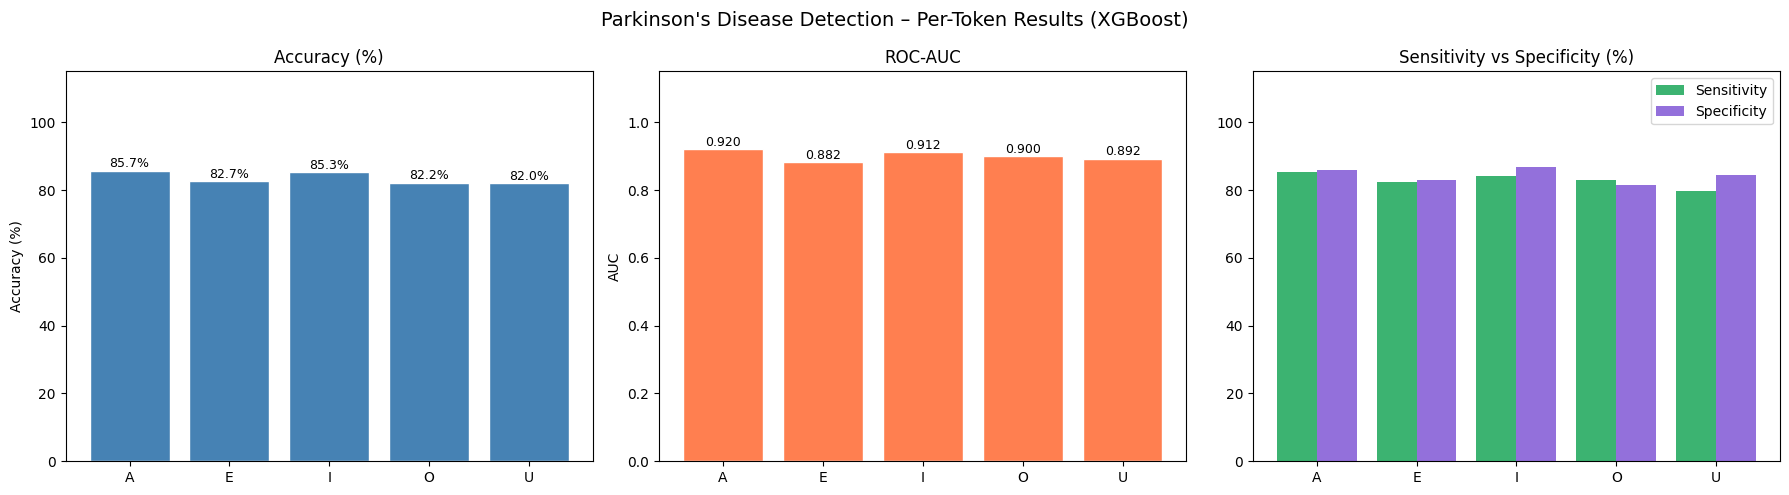

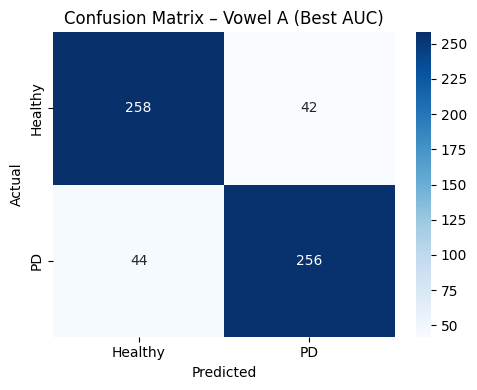

✅ Graphs saved to pd_sota_results/graphs/


In [18]:
# ── CELL 18: Visualizations ────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Parkinson\'s Disease Detection – Per-Token Results (XGBoost)', fontsize=14)

vowels_plot = list(vowel_results.keys())
accs  = [vowel_results[v]['accuracy']*100  for v in vowels_plot]
aucs  = [vowel_results[v]['roc_auc']       for v in vowels_plot]
mccs  = [vowel_results[v]['mcc']           for v in vowels_plot]

# Accuracy bar
bars = axes[0].bar(vowels_plot, accs, color='steelblue', edgecolor='white')
axes[0].set_ylim(0, 115)
axes[0].set_title('Accuracy (%)')
axes[0].set_ylabel('Accuracy (%)')
for bar, val in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{val:.1f}%', ha='center', fontsize=9)

# AUC bar
bars2 = axes[1].bar(vowels_plot, aucs, color='coral', edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('ROC-AUC')
axes[1].set_ylabel('AUC')
for bar, val in zip(bars2, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

# Sensitivity vs Specificity
sens = [vowel_results[v]['sensitivity']*100 for v in vowels_plot]
spec = [vowel_results[v]['specificity']*100 for v in vowels_plot]
x_ = np.arange(len(vowels_plot))
axes[2].bar(x_ - 0.2, sens, 0.4, label='Sensitivity', color='mediumseagreen')
axes[2].bar(x_ + 0.2, spec, 0.4, label='Specificity', color='mediumpurple')
axes[2].set_xticks(x_)
axes[2].set_xticklabels(vowels_plot)
axes[2].set_ylim(0, 115)
axes[2].set_title('Sensitivity vs Specificity (%)')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graphs', 'per_vowel_metrics.png'), dpi=150)
plt.show()

# Confusion matrix for best vowel
best_vowel = max(vowel_results, key=lambda v: vowel_results[v]['roc_auc'])
cm = vowel_results[best_vowel]['cm']
fig2, ax2 = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Healthy','PD'], yticklabels=['Healthy','PD'])
ax2.set_title(f'Confusion Matrix – Vowel {best_vowel} (Best AUC)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graphs', 'confusion_matrix_best.png'), dpi=150)
plt.show()

print(f'✅ Graphs saved to {OUTPUT_DIR}/graphs/')

In [19]:
# ── CELL 19: Feature Importance ───────────────────────────────────────────────

FEATURE_NAMES = (
    [f'MFCC_{i}'   for i in range(13)] +
    [f'DMFCC_{i}'  for i in range(13)] +
    [f'DDMFCC_{i}' for i in range(13)] +
    ['PPQ','APQ','HE','GNER','HRes','HSR','HNR','HNR_std','CPP'] +
    ['Shannon','Renyi','PermEnt','ApproxEnt','SpectralEnt'] +
    [f'WPT_E_{i}'  for i in range(16)] +
    [f'WPT_Ne_{i}' for i in range(16)] +
    ['TremBand_2-4_E','TremBand_2-4_std',
     'TremBand_4-7_E','TremBand_4-7_std',
     'TremBand_7-12_E','TremBand_7-12_std',
     'TremBand_12-20_E','TremBand_12-20_std',
     'TBR',
     'IF_std_0','IF_std_1','IF_std_2','IF_std_3'] +
    ['DWT_d3_E','DWT_d3_std','DWT_d3_kurt','DWT_d3_skew',
     'DWT_d2_E','DWT_d2_std','DWT_d2_kurt','DWT_d2_skew',
     'DWT_d1_E','DWT_d1_std','DWT_d1_kurt','DWT_d1_skew']
)
FEATURE_NAMES = FEATURE_NAMES[:TOTAL_FEAT]  # trim to actual size

# Get importance from best vowel's last fold XGBoost
best_v = max(vowel_results, key=lambda v: vowel_results[v]['roc_auc'])
pipe_fi = vowel_pipelines[best_v]['xgb'][-1]
selector = pipe_fi.named_steps['select']
clf      = pipe_fi.named_steps['clf']

selected_idx = selector.get_support(indices=True)
importances  = clf.feature_importances_

top_n = 20
top_idx = np.argsort(importances)[-top_n:][::-1]
top_feat_names = [FEATURE_NAMES[selected_idx[i]] if i < len(selected_idx) else f'f{i}' for i in top_idx]
top_feat_vals  = importances[top_idx]

fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.barh(range(top_n), top_feat_vals[::-1], color='teal')
ax3.set_yticks(range(top_n))
ax3.set_yticklabels(top_feat_names[::-1])
ax3.set_xlabel('Feature Importance (XGBoost)')
ax3.set_title(f'Top {top_n} Features – Vowel {best_v}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'graphs', 'feature_importance.png'), dpi=150)
plt.show()
print('✅ Feature importance plotted')

IndexError: list index out of range

In [ ]:
# ── CELL 20: Final Summary Print ──────────────────────────────────────────────

print('='*65)
print(' PARKINSON\'S DISEASE DETECTION – FINAL RESULTS')
print('='*65)
print(f' Dataset  : PC-GITA | Sustained Vowels')
print(f' Features : {TOTAL_FEAT}D (MFCC-39 + Breathiness-9 + Entropy-5 + Wavelet-57)')
print(f' Model    : XGBoost + SelectKBest + RobustScaler')
print(f' CV       : Speaker-Independent StratifiedGroupKFold ({N_FOLDS} folds)')
print('-'*65)
print(df_results.to_string(index=False))
print('='*65)
if fusion_m:
    best_auc = fusion_m['roc_auc']
    print(f' BEST SPEAKER-LEVEL AUC: {best_auc:.4f}')
else:
    best_v   = max(vowel_results, key=lambda v: vowel_results[v]['roc_auc'])
    best_auc = vowel_results[best_v]['roc_auc']
    print(f' BEST VOWEL AUC ({best_v}): {best_auc:.4f}')
print('='*65)